## 1. CONFIGURACIÓN E IMPORTACIÓN DE LIBRERÍAS

In [124]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr, kruskal, mannwhitneyu
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('default')
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.3f}' if abs(x) < 1000 else f'{x:,.0f}')

print("✓ Librerías cargadas correctamente")

✓ Librerías cargadas correctamente


## 2. CARGA Y EXPLORACIÓN INICIAL

In [125]:
# Cargar datos
try:
    df = pd.read_csv('spotify_2015_2025_85k.csv')
    print(f"✓ Datos cargados correctamente")
    print(f"✓ Dimensiones: {df.shape}")
    print(f"\n✓ Columnas disponibles:")
    print(df.columns.tolist())
except FileNotFoundError:
    print("✗ Archivo no encontrado")
    exit()

# Información general
print(f"\n✓ Primeras filas:")
df.head()

✓ Datos cargados correctamente
✓ Dimensiones: (85000, 19)

✓ Columnas disponibles:
['track_id', 'track_name', 'artist_name', 'album_name', 'release_date', 'genre', 'duration_ms', 'popularity', 'danceability', 'energy', 'key', 'loudness', 'mode', 'instrumentalness', 'tempo', 'stream_count', 'country', 'explicit', 'label']

✓ Primeras filas:


,track_id,track_name,artist_name,album_name,release_date,genre,duration_ms,popularity,danceability,energy,key,loudness,mode,instrumentalness,tempo,stream_count,country,explicit,label
0,TRK-BEBD53DA84E1,Agent every (0),Noah Rhodes,Beautiful instead,2016-04-01,Pop,234194,55,0.150,0.740,9,-32.220,0,0.436,73.120,13000,Brazil,0,Universal Music
1,TRK-6A32496762D7,Night respond,Jennifer Cole,Table,2022-04-15,Metal,375706,45,0.440,0.460,0,-14.020,0,0.223,157.740,1000,France,1,Island Records
2,TRK-47AA7523463E,Future choice whatever,Brandon Davis,Page southern,2016-02-23,Rock,289191,55,0.620,0.800,8,-48.260,1,0.584,71.030,1000,Germany,1,XL Recordings
3,TRK-25ADA22E3B06,Bad fall pick those,Corey Jones,Spring,2015-10-12,Pop,209484,51,0.780,0.980,1,-34.470,1,0.684,149.000,1000,France,0,Warner Music
4,TRK-9245F2AD996A,Husband,Mark Diaz,Great prove,2022-07-08,Indie,127435,39,0.740,0.180,10,-17.840,0,0.304,155.850,2000,United States,0,Independent


---
# PARTE 1: ANÁLISIS EXPLORATORIO (EDA)
## Popularidad vs Danceability

In [126]:
print("="*60)
print("ANÁLISIS EXPLORATORIO: POPULARIDAD vs DANCEABILITY")
print("="*60)

# Limpiar datos
data_eda = df[['popularity', 'danceability']].dropna()
print(f"\nRegistros válidos para análisis: {len(data_eda)} de {len(df)} totales")
print(f"Porcentaje de datos válidos: {(len(data_eda)/len(df)*100):.1f}%")

# TABLA 1: ESTADÍSTICAS DESCRIPTIVAS
print("\n" + "-"*60)
print("TABLA 1: ESTADÍSTICAS DESCRIPTIVAS")
print("-"*60)

desc_stats = pd.DataFrame({
    'Variable': ['Popularity', 'Danceability'],
    'N': [len(data_eda['popularity']), len(data_eda['danceability'])],
    'Media': [data_eda['popularity'].mean(), data_eda['danceability'].mean()],
    'Mediana': [data_eda['popularity'].median(), data_eda['danceability'].median()],
    'Desv. Estándar': [data_eda['popularity'].std(), data_eda['danceability'].std()],
    'Mínimo': [data_eda['popularity'].min(), data_eda['danceability'].min()],
    'Máximo': [data_eda['popularity'].max(), data_eda['danceability'].max()],
    'Rango': [data_eda['popularity'].max() - data_eda['popularity'].min(), 
              data_eda['danceability'].max() - data_eda['danceability'].min()]
})

print("\nEstadísticas Descriptivas:")
print(desc_stats.round(3).to_string(index=False))

ANÁLISIS EXPLORATORIO: POPULARIDAD vs DANCEABILITY

Registros válidos para análisis: 85000 de 85000 totales
Porcentaje de datos válidos: 100.0%

------------------------------------------------------------
TABLA 1: ESTADÍSTICAS DESCRIPTIVAS
------------------------------------------------------------

Estadísticas Descriptivas:
    Variable     N  Media  Mediana  Desv. Estándar  Mínimo  Máximo   Rango
  Popularity 85000 48.163   47.000          14.830   0.000 100.000 100.000
Danceability 85000  0.521    0.520           0.271   0.050   0.990   0.940


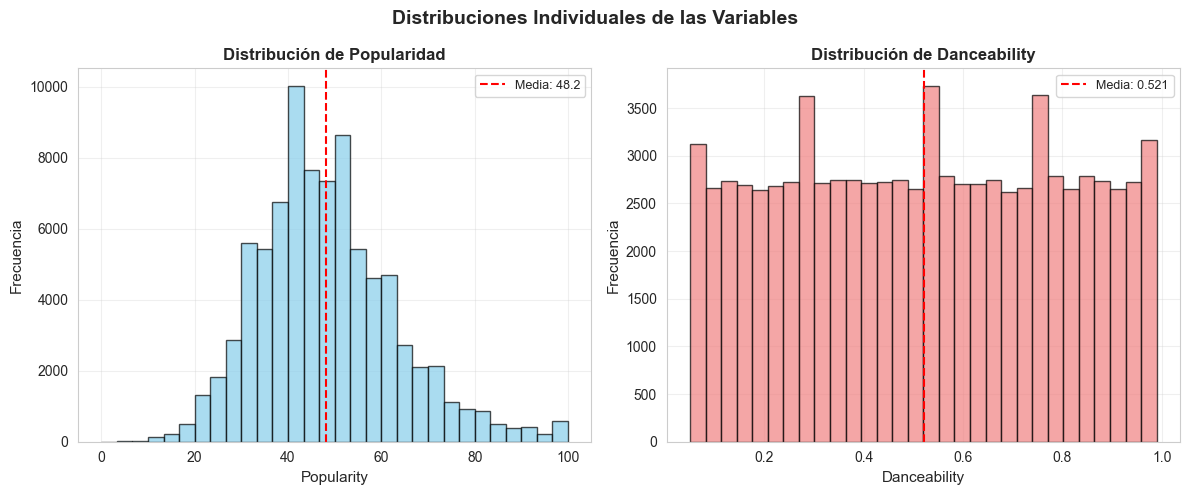

In [127]:
# GRÁFICO 1: HISTOGRAMAS INDIVIDUALES
fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Histograma de popularidad
ax1.hist(data_eda['popularity'], bins=30, edgecolor='black', alpha=0.7, color='skyblue')
ax1.set_xlabel('Popularity', fontsize=11)
ax1.set_ylabel('Frecuencia', fontsize=11)
ax1.set_title('Distribución de Popularidad', fontsize=12, fontweight='bold')
ax1.axvline(data_eda['popularity'].mean(), color='red', linestyle='--', 
           label=f'Media: {data_eda["popularity"].mean():.1f}')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Histograma de danceability
ax2.hist(data_eda['danceability'], bins=30, edgecolor='black', alpha=0.7, color='lightcoral')
ax2.set_xlabel('Danceability', fontsize=11)
ax2.set_ylabel('Frecuencia', fontsize=11)
ax2.set_title('Distribución de Danceability', fontsize=12, fontweight='bold')
ax2.axvline(data_eda['danceability'].mean(), color='red', linestyle='--',
           label=f'Media: {data_eda["danceability"].mean():.3f}')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.suptitle('Distribuciones Individuales de las Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [128]:
# ANÁLISIS DE CORRELACIÓN
print("\n" + "-"*60)
print("ANÁLISIS DE CORRELACIÓN")
print("-"*60)

corr_pearson, p_pearson = pearsonr(data_eda['popularity'], data_eda['danceability'])
corr_spearman, p_spearman = spearmanr(data_eda['popularity'], data_eda['danceability'])

# Crear tabla de correlaciones
corr_table = pd.DataFrame({
    'Método': ['Pearson', 'Spearman'],
    'Coeficiente': [corr_pearson, corr_spearman],
    'p-valor': [p_pearson, p_spearman],
    'Interpretación': [
        'Correlación lineal' if p_pearson < 0.05 else 'Sin correlación lineal significativa',
        'Correlación monótona' if p_spearman < 0.05 else 'Sin correlación monótona significativa'
    ]
})

print("\nTabla de Correlaciones:")
print(corr_table.round(4).to_string(index=False))

# Interpretación
print("\nINTERPRETACIÓN:")
if abs(corr_pearson) < 0.1:
    fuerza = "prácticamente nula"
elif abs(corr_pearson) < 0.3:
    fuerza = "débil"
elif abs(corr_pearson) < 0.5:
    fuerza = "moderada"
elif abs(corr_pearson) < 0.7:
    fuerza = "fuerte"
else:
    fuerza = "muy fuerte"

direccion = "positiva" if corr_pearson > 0 else "negativa"

print(f"• Existe una relación {fuerza} y {direccion} entre danceability y popularidad.")
if p_pearson < 0.05:
    print(f"• La relación es estadísticamente significativa (p = {p_pearson:.4f})")
else:
    print(f"• La relación NO es estadísticamente significativa (p = {p_pearson:.4f})")


------------------------------------------------------------
ANÁLISIS DE CORRELACIÓN
------------------------------------------------------------

Tabla de Correlaciones:
  Método  Coeficiente  p-valor                         Interpretación
 Pearson        0.003    0.352   Sin correlación lineal significativa
Spearman        0.001    0.752 Sin correlación monótona significativa

INTERPRETACIÓN:
• Existe una relación prácticamente nula y positiva entre danceability y popularidad.
• La relación NO es estadísticamente significativa (p = 0.3519)


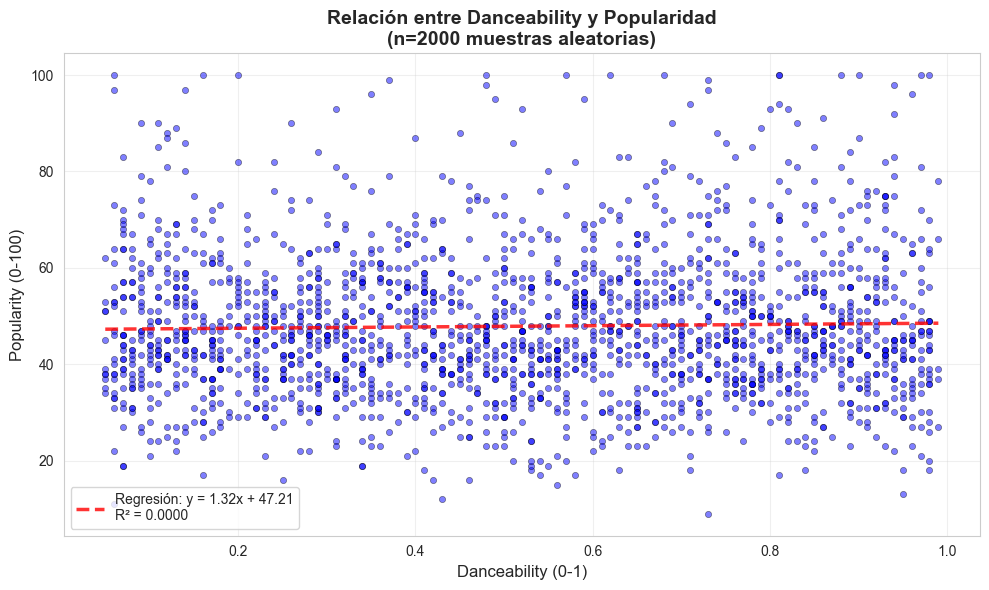

In [129]:
# GRÁFICO 2: DIAGRAMA DE DISPERSIÓN
fig2, ax = plt.subplots(figsize=(10, 6))

# Muestra aleatoria para evitar sobrecarga
sample_size = min(2000, len(data_eda))
sample_data = data_eda.sample(n=sample_size, random_state=42)

# Diagrama de dispersión
scatter = ax.scatter(sample_data['danceability'], sample_data['popularity'],
                     alpha=0.5, s=20, c='blue', edgecolors='black', linewidth=0.5)
ax.set_xlabel('Danceability (0-1)', fontsize=12)
ax.set_ylabel('Popularity (0-100)', fontsize=12)
ax.set_title(f'Relación entre Danceability y Popularidad\n(n={sample_size} muestras aleatorias)', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

# Línea de regresión
z = np.polyfit(sample_data['danceability'], sample_data['popularity'], 1)
p = np.poly1d(z)
x_range = np.linspace(sample_data['danceability'].min(), 
                     sample_data['danceability'].max(), 100)
ax.plot(x_range, p(x_range), 'r--', alpha=0.8, linewidth=2.5, 
        label=f'Regresión: y = {z[0]:.2f}x + {z[1]:.2f}\nR² = {corr_pearson**2:.4f}')

ax.legend(fontsize=10, loc='best')
plt.tight_layout()
plt.show()

In [130]:
# ANÁLISIS POR QUINTILES
print("\n" + "-"*60)
print("ANÁLISIS POR QUINTILES DE DANCEABILITY")
print("-"*60)

# Crear quintiles
data_eda_copy = data_eda.copy()
data_eda_copy['dance_quintile'] = pd.qcut(data_eda_copy['danceability'], q=5, 
                                labels=['Q1 (Muy baja)', 'Q2 (Baja)', 'Q3 (Media)', 
                                        'Q4 (Alta)', 'Q5 (Muy alta)'])

# Calcular estadísticas por quintil
quintile_stats = data_eda_copy.groupby('dance_quintile').agg({
    'danceability': ['mean', 'min', 'max'],
    'popularity': ['count', 'mean', 'median', 'std', 'min', 'max']
}).round(3)

# Renombrar columnas
quintile_stats.columns = ['Dance_mean', 'Dance_min', 'Dance_max',
                         'N', 'Pop_mean', 'Pop_median', 'Pop_std', 'Pop_min', 'Pop_max']

print("\nTabla: Estadísticas por Quintil de Danceability")
print("-"*60)
print(quintile_stats.to_string())


------------------------------------------------------------
ANÁLISIS POR QUINTILES DE DANCEABILITY
------------------------------------------------------------

Tabla: Estadísticas por Quintil de Danceability
------------------------------------------------------------
                Dance_mean  Dance_min  Dance_max      N  Pop_mean  Pop_median  Pop_std  Pop_min  Pop_max
dance_quintile                                                                                          
Q1 (Muy baja)        0.147      0.050      0.240  17428    48.081      47.000   14.836        2      100
Q2 (Baja)            0.340      0.250      0.430  17243    48.108      47.000   14.664        5      100
Q3 (Media)           0.525      0.440      0.610  16469    48.209      47.000   14.742        2      100
Q4 (Alta)            0.710      0.620      0.800  17142    48.278      47.000   14.852        2      100
Q5 (Muy alta)        0.898      0.810      0.990  16718    48.142      46.000   15.057        0   

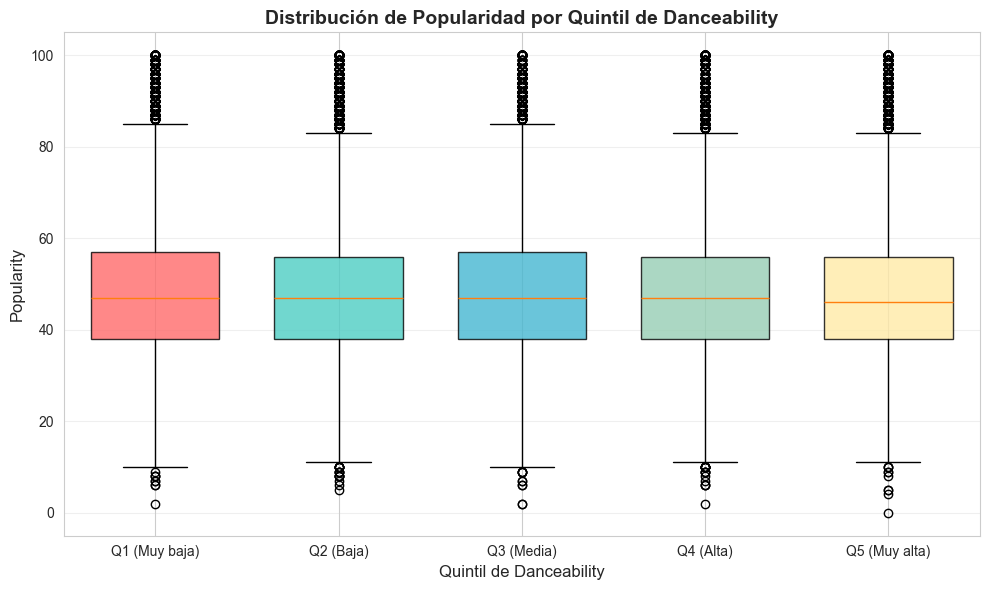

In [131]:
# GRÁFICO 3: DIAGRAMA DE CAJAS POR QUINTILES
fig3, ax = plt.subplots(figsize=(10, 6))

# Preparar datos para boxplot
box_data = []
labels = []
for q in data_eda_copy['dance_quintile'].cat.categories:
    q_data = data_eda_copy[data_eda_copy['dance_quintile'] == q]['popularity']
    if len(q_data) > 0:
        box_data.append(q_data.values)
        labels.append(str(q))

# Crear boxplot
bp = ax.boxplot(box_data, labels=labels, patch_artist=True, widths=0.7)

# Colorear las cajas
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

# Personalizar
ax.set_xlabel('Quintil de Danceability', fontsize=12)
ax.set_ylabel('Popularity', fontsize=12)
ax.set_title('Distribución de Popularidad por Quintil de Danceability', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

---
# PARTE 2: PRUEBA DE KRUSKAL-WALLIS
## Popularidad por Género Musical

---
## 5.1 VALIDACIÓN PREVIA: Análisis de Normalidad de POPULARITY

Antes de aplicar pruebas de hipótesis paramétricas (ANOVA) o no paramétricas (Kruskal-Wallis), validamos si la variable **popularity** sigue una distribución normal.
Si no es normal, justificamos el uso de **métodos no paramétricos** (Kruskal-Wallis en lugar de ANOVA).


VALIDACIÓN: ANÁLISIS DE NORMALIDAD DE POPULARITY

Tamaño de la muestra: 85,000 registros

• Media: 48.16
• Mediana: 47.00
• Desviación estándar: 14.83
• Asimetría (skewness): 0.6657
• Curtosis: 0.7610

----------------------------------------------------------------------
TEST 1: D'AGOSTINO-PEARSON (K² test)
----------------------------------------------------------------------
(Recomendado para muestras > 5,000)

  Estadístico K²: 6344.4760
  p-valor: 0.00e+00

  ✗ CONCLUSIÓN: p < 0.05
  → Se RECHAZA H₀ (hipótesis de normalidad)
  → Los datos NO siguen distribución normal
  → La evidencia contra la normalidad es MUY FUERTE

----------------------------------------------------------------------
TEST 2: SHAPIRO-WILK
----------------------------------------------------------------------
(Limitado a muestras ≤ 5,000; usamos muestra aleatoria)

  Muestra usada: 5,000 registros
  Estadístico W: 0.9716
  p-valor: 2.18e-30

  ✗ Se RECHAZA normalidad (p < 0.05)

------------------------------

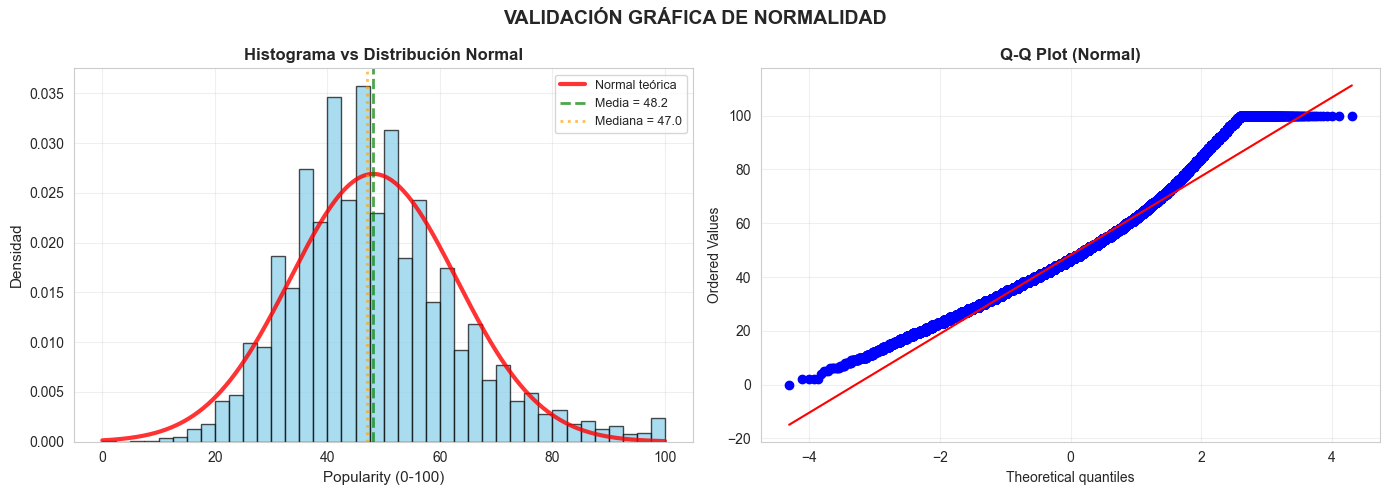


CONCLUSIÓN ESTADÍSTICA FINAL

RESULTADOS:
  • Test D'Agostino-Pearson: p = 0.00e+00
  • Asimetría: 0.6657
  • Curtosis: 0.7610
  • Media-Mediana: 1.16 puntos

📊 DECISIÓN FINAL:
   La variable POPULARITY NO sigue distribución normal.

   ✓ JUSTIFICACIÓN:
     - p-valor extremadamente pequeño (0.00e+00)
     - Asimetría significativa: 0.6657
     - Diferencia media-mediana: 1.16 puntos

   ✓ CONSECUENCIA:
     → SE RECOMIENDAN MÉTODOS NO PARAMÉTRICOS
     → KRUSKAL-WALLIS es apropiado (en lugar de ANOVA)
     → Esta justificación es ESTADÍSTICAMENTE SÓLIDA


In [132]:
# ============================================================================
# ANÁLISIS DE NORMALIDAD DE LA VARIABLE POPULARITY (MUESTRA GRANDE: 85K)
# ============================================================================
from scipy.stats import normaltest, skew, kurtosis, shapiro, norm

print("\n" + "="*70)
print("VALIDACIÓN: ANÁLISIS DE NORMALIDAD DE POPULARITY")
print("="*70)

# Preparar datos
popularity_data = data_eda['popularity'].dropna()
n_obs = len(popularity_data)
print(f"\nTamaño de la muestra: {n_obs:,} registros")

# Estadísticas básicas
mu = popularity_data.mean()
mediana = popularity_data.median()
sigma = popularity_data.std()
skewness = skew(popularity_data)
kurt = kurtosis(popularity_data)

print(f"\n• Media: {mu:.2f}")
print(f"• Mediana: {mediana:.2f}")
print(f"• Desviación estándar: {sigma:.2f}")
print(f"• Asimetría (skewness): {skewness:.4f}")
print(f"• Curtosis: {kurt:.4f}")

# TEST 1: D'Agostino-Pearson (óptimo para muestras grandes > 5,000)
print("\n" + "-"*70)
print("TEST 1: D'AGOSTINO-PEARSON (K² test)")
print("-"*70)
print("(Recomendado para muestras > 5,000)\n")

stat_dagostino, p_dagostino = normaltest(popularity_data)
print(f"  Estadístico K²: {stat_dagostino:.4f}")
print(f"  p-valor: {p_dagostino:.2e}")

if p_dagostino < 0.05:
    print(f"\n  ✗ CONCLUSIÓN: p < 0.05")
    print(f"  → Se RECHAZA H₀ (hipótesis de normalidad)")
    print(f"  → Los datos NO siguen distribución normal")
    print(f"  → La evidencia contra la normalidad es MUY FUERTE")
else:
    print(f"\n  ✓ CONCLUSIÓN: p ≥ 0.05")
    print(f"  → NO se rechaza H₀")
    print(f"  → Posible distribución normal")

# TEST 2: Shapiro-Wilk (sobre muestra aleatoria si N > 5000)
print("\n" + "-"*70)
print("TEST 2: SHAPIRO-WILK")
print("-"*70)
print("(Limitado a muestras ≤ 5,000; usamos muestra aleatoria)\n")

sample_size = min(5000, n_obs)
sample_for_shapiro = popularity_data.sample(n=sample_size, random_state=42)

stat_shapiro, p_shapiro = shapiro(sample_for_shapiro)
print(f"  Muestra usada: {sample_size:,} registros")
print(f"  Estadístico W: {stat_shapiro:.4f}")
print(f"  p-valor: {p_shapiro:.2e}")

if p_shapiro < 0.05:
    print(f"\n  ✗ Se RECHAZA normalidad (p < 0.05)")
else:
    print(f"\n  ✓ No se rechaza normalidad (p ≥ 0.05)")

# ANÁLISIS DE FORMA
print("\n" + "-"*70)
print("ANÁLISIS DE FORMA: ASIMETRÍA Y CURTOSIS")
print("-"*70)

print(f"\nAsimetría (skewness): {skewness:.4f}")
if abs(skewness) < 0.1:
    print("  → Distribución prácticamente SIMÉTRICA")
elif abs(skewness) < 0.5:
    print("  → Distribución MODERADAMENTE ASIMÉTRICA")
    if skewness > 0:
        print(f"     (asimetría POSITIVA: Media ({mu:.1f}) > Mediana ({mediana:.1f}))")
    else:
        print(f"     (asimetría NEGATIVA: Media ({mu:.1f}) < Mediana ({mediana:.1f}))")
else:
    print("  → Distribución ALTAMENTE ASIMÉTRICA")
    if skewness > 0:
        print(f"     (asimetría POSITIVA: Media ({mu:.1f}) > Mediana ({mediana:.1f}))")
    else:
        print(f"     (asimetría NEGATIVA: Media ({mu:.1f}) < Mediana ({mediana:.1f}))")

print(f"\nCurtosis: {kurt:.4f}")
if abs(kurt) < 0.5:
    print("  → Curtosis similar a la NORMAL (mesocúrtica)")
elif kurt > 0.5:
    print("  → Distribución LEPTOCÚRTICA (más puntiaguda)")
else:
    print("  → Distribución PLATICÚRTICA (más plana)")

# VALIDACIÓN NUMÉRICA: Regla 68-95-99.7
print("\n" + "-"*70)
print("VALIDACIÓN NUMÉRICA: REGLA 68-95-99.7")
print("-"*70)

within_1sigma = ((popularity_data >= mu - sigma) & 
                 (popularity_data <= mu + sigma)).mean() * 100
within_2sigma = ((popularity_data >= mu - 2*sigma) & 
                 (popularity_data <= mu + 2*sigma)).mean() * 100
within_3sigma = ((popularity_data >= mu - 3*sigma) & 
                 (popularity_data <= mu + 3*sigma)).mean() * 100

print(f"\n  Dentro de ±1σ: Teórico 68.3% | Observado {within_1sigma:.1f}% | Diferencia {within_1sigma-68.3:+.1f}%")
print(f"  Dentro de ±2σ: Teórico 95.4% | Observado {within_2sigma:.1f}% | Diferencia {within_2sigma-95.4:+.1f}%")
print(f"  Dentro de ±3σ: Teórico 99.7% | Observado {within_3sigma:.1f}% | Diferencia {within_3sigma-99.7:+.1f}%")

# VALIDACIÓN GRÁFICA
print("\n" + "-"*70)
print("VALIDACIÓN GRÁFICA")
print("-"*70)

fig_norm, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Histograma + Distribución Normal Teórica
n_hist, bins, patches = ax1.hist(popularity_data, bins=40, density=True, 
                                  alpha=0.7, color='skyblue', edgecolor='black')

xmin, xmax = popularity_data.min(), popularity_data.max()
x = np.linspace(xmin, xmax, 1000)
p_normal = norm.pdf(x, mu, sigma)
ax1.plot(x, p_normal, 'r-', linewidth=3, alpha=0.8, label='Normal teórica')

ax1.axvline(mu, color='green', linestyle='--', linewidth=2, alpha=0.7, 
            label=f'Media = {mu:.1f}')
ax1.axvline(mediana, color='orange', linestyle=':', linewidth=2, alpha=0.7, 
            label=f'Mediana = {mediana:.1f}')

ax1.set_xlabel('Popularity (0-100)', fontsize=11)
ax1.set_ylabel('Densidad', fontsize=11)
ax1.set_title('Histograma vs Distribución Normal', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Panel 2: Q-Q Plot
stats.probplot(popularity_data, dist='norm', plot=ax2)
ax2.set_title('Q-Q Plot (Normal)', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.suptitle('VALIDACIÓN GRÁFICA DE NORMALIDAD', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# CONCLUSIÓN FINAL
print("\n" + "="*70)
print("CONCLUSIÓN ESTADÍSTICA FINAL")
print("="*70)

print(f"\nRESULTADOS:")
print(f"  • Test D'Agostino-Pearson: p = {p_dagostino:.2e}")
print(f"  • Asimetría: {skewness:.4f}")
print(f"  • Curtosis: {kurt:.4f}")
print(f"  • Media-Mediana: {abs(mu - mediana):.2f} puntos")

if p_dagostino < 0.05:
    print("\n📊 DECISIÓN FINAL:")
    print("   La variable POPULARITY NO sigue distribución normal.")
    print("\n   ✓ JUSTIFICACIÓN:")
    print(f"     - p-valor extremadamente pequeño ({p_dagostino:.2e})")
    print(f"     - Asimetría significativa: {skewness:.4f}")
    print(f"     - Diferencia media-mediana: {abs(mu - mediana):.2f} puntos")
    print("\n   ✓ CONSECUENCIA:")
    print("     → SE RECOMIENDAN MÉTODOS NO PARAMÉTRICOS")
    print("     → KRUSKAL-WALLIS es apropiado (en lugar de ANOVA)")
    print("     → Esta justificación es ESTADÍSTICAMENTE SÓLIDA")
else:
    print("\n📊 DECISIÓN FINAL:")
    print("   No se rechaza la normalidad (p ≥ 0.05).")

In [133]:
print("="*60)
print("ANÁLISIS KRUSKAL-WALLIS: POPULARIDAD POR GÉNERO")
print("="*60)

# Limpiar datos
data_kw = df[['popularity', 'genre']].dropna()
print(f"\n✓ Registros válidos para análisis: {len(data_kw)}")
print(f"✓ Porcentaje de datos válidos: {(len(data_kw)/len(df)*100):.1f}%")

# ANÁLISIS PRELIMINAR: Distribución de géneros
print("\n" + "-"*60)
print("1. DISTRIBUCIÓN DE GÉNEROS MUSICALES")
print("-"*60)

genre_counts = data_kw['genre'].value_counts()
print(f"Número de géneros únicos: {len(genre_counts)}")
print(f"\nTop 10 géneros más frecuentes:")
print(genre_counts.head(10).to_string())

ANÁLISIS KRUSKAL-WALLIS: POPULARIDAD POR GÉNERO

✓ Registros válidos para análisis: 85000
✓ Porcentaje de datos válidos: 100.0%

------------------------------------------------------------
1. DISTRIBUCIÓN DE GÉNEROS MUSICALES
------------------------------------------------------------
Número de géneros únicos: 12

Top 10 géneros más frecuentes:
genre
Metal        7200
Jazz         7177
Hip-Hop      7160
Classical    7158
Rock         7113
Pop          7096
R&B          7084
Folk         7080
Country      7030
Indie        7007

✓ Registros válidos para análisis: 85000
✓ Porcentaje de datos válidos: 100.0%

------------------------------------------------------------
1. DISTRIBUCIÓN DE GÉNEROS MUSICALES
------------------------------------------------------------
Número de géneros únicos: 12

Top 10 géneros más frecuentes:
genre
Metal        7200
Jazz         7177
Hip-Hop      7160
Classical    7158
Rock         7113
Pop          7096
R&B          7084
Folk         7080
Country      7

In [134]:
# Seleccionar géneros con suficiente muestra
min_samples = 30
genres_to_analyze = genre_counts[genre_counts >= min_samples].index.tolist()
filtered_data_kw = data_kw[data_kw['genre'].isin(genres_to_analyze)]

print(f"✓ Géneros con al menos {min_samples} observaciones: {len(genres_to_analyze)}")
print(f"✓ Registros en análisis final: {len(filtered_data_kw)}")

# ESTADÍSTICAS DESCRIPTIVAS POR GÉNERO
print("\n" + "-"*60)
print("2. ESTADÍSTICAS DESCRIPTIVAS POR GÉNERO")
print("-"*60)

genre_stats = filtered_data_kw.groupby('genre')['popularity'].agg([
    'count', 'mean', 'median', 'std', 'min', 'max'
]).round(2).sort_values('mean', ascending=False)

print("\nEstadísticas de Popularidad por Género (ordenados por media):")
print(genre_stats.to_string())

✓ Géneros con al menos 30 observaciones: 12
✓ Registros en análisis final: 85000

------------------------------------------------------------
2. ESTADÍSTICAS DESCRIPTIVAS POR GÉNERO
------------------------------------------------------------

Estadísticas de Popularidad por Género (ordenados por media):
           count   mean  median    std  min  max
genre                                           
Pop         7096 48.370  47.000 15.000    7  100
Classical   7158 48.360  47.000 14.830    8  100
Hip-Hop     7160 48.360  47.000 15.090    2  100
R&B         7084 48.360  47.000 15.200    4  100
EDM         6894 48.200  47.000 14.740    2  100
Metal       7200 48.190  47.000 14.750    0  100
Country     7030 48.170  46.000 14.850    6  100
Indie       7007 48.120  47.000 14.580    5  100
Folk        7080 48.100  47.000 14.970    6  100
Rock        7113 47.970  46.000 14.790    5  100
Reggaeton   7001 47.880  46.000 14.500    6  100
Jazz        7177 47.850  46.000 14.640    6  100


In [135]:
# PRUEBA DE KRUSKAL-WALLIS
print("\n" + "-"*60)
print("3. PRUEBA DE KRUSKAL-WALLIS")
print("-"*60)

# Preparar datos para Kruskal-Wallis
samples = []
genre_names = []

for genre in genres_to_analyze:
    genre_popularity = filtered_data_kw[filtered_data_kw['genre'] == genre]['popularity'].values
    if len(genre_popularity) > 0:
        samples.append(genre_popularity)
        genre_names.append(genre)

# Ejecutar prueba de Kruskal-Wallis
h_statistic, p_value_kw = kruskal(*samples)

print(f"\nH estadístico (Kruskal-Wallis): {h_statistic:.4f}")
print(f"p-valor: {p_value_kw:.4e}")

# Interpretación
print("\nINTERPRETACIÓN:")
print("-"*40)

if p_value_kw < 0.05:
    print("✓ Se rechaza la hipótesis nula (p < 0.05)")
    print("✓ Existen diferencias estadísticamente significativas")
    print("  en la popularidad entre al menos dos géneros musicales")
else:
    print("✗ No se rechaza la hipótesis nula (p ≥ 0.05)")
    print("✗ No hay evidencia suficiente de diferencias")
    print("  en la popularidad entre los géneros analizados")


------------------------------------------------------------
3. PRUEBA DE KRUSKAL-WALLIS
------------------------------------------------------------

H estadístico (Kruskal-Wallis): 10.9189
p-valor: 4.5009e-01

INTERPRETACIÓN:
----------------------------------------
✗ No se rechaza la hipótesis nula (p ≥ 0.05)
✗ No hay evidencia suficiente de diferencias
  en la popularidad entre los géneros analizados



------------------------------------------------------------
4. VISUALIZACIÓN DE RESULTADOS
------------------------------------------------------------


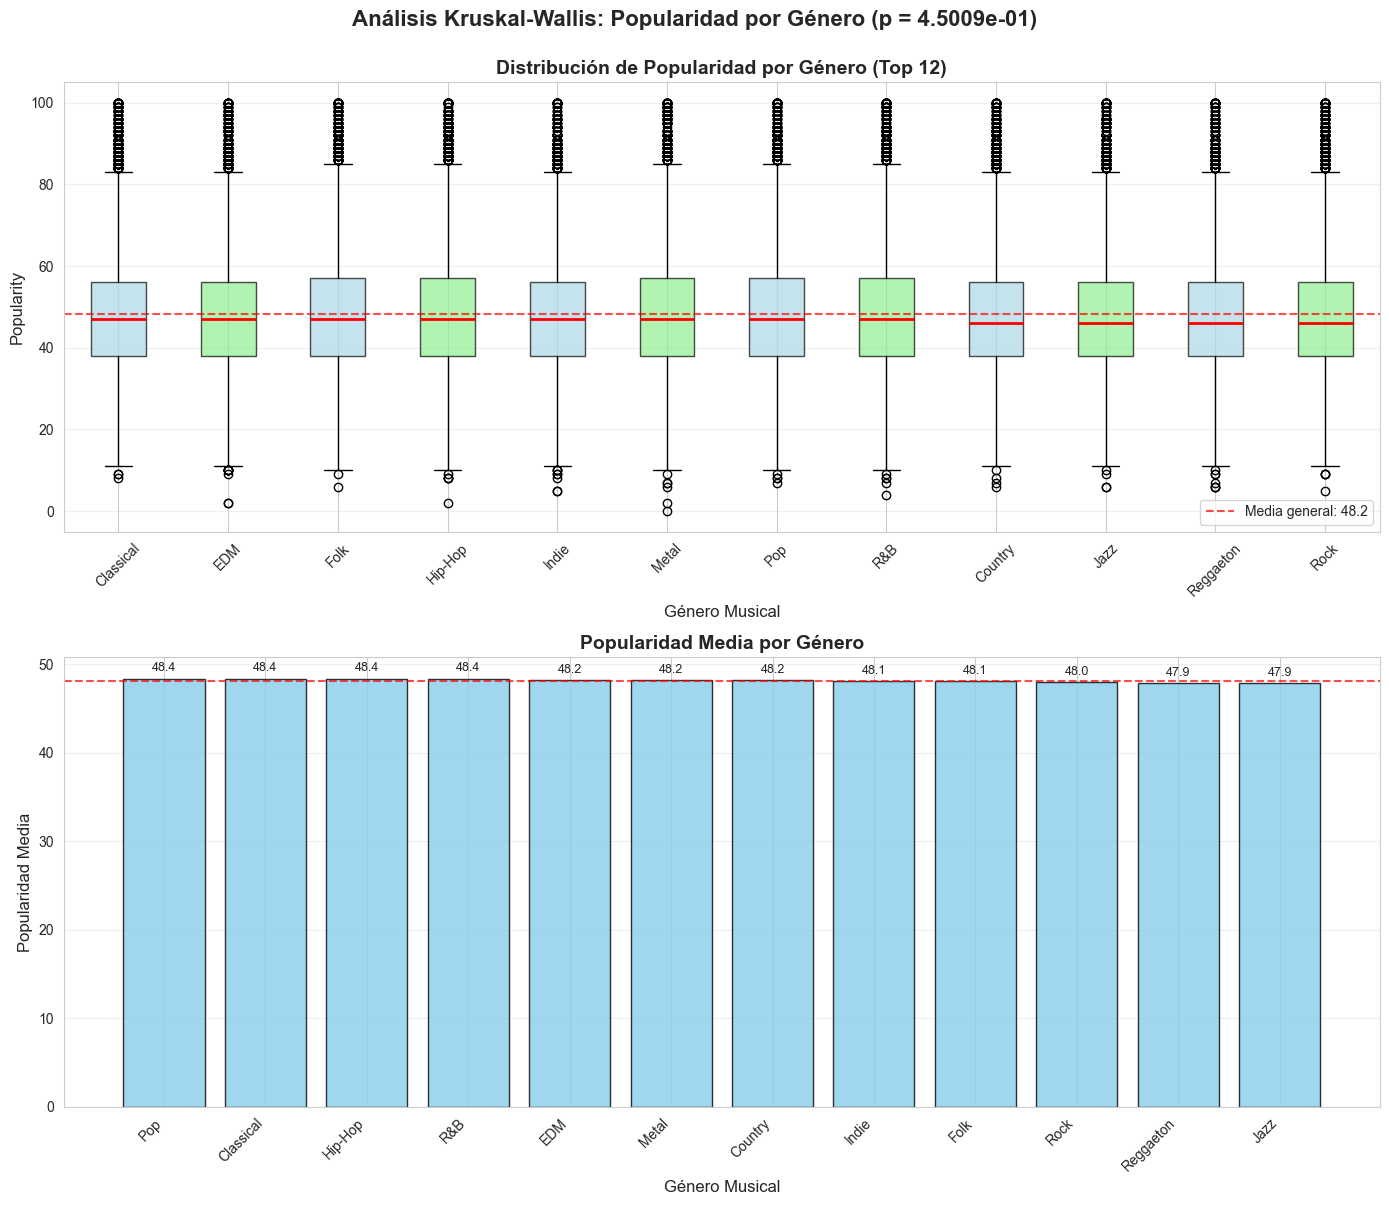

In [136]:
# VISUALIZACIÓN: Boxplot de popularidad por género
print("\n" + "-"*60)
print("4. VISUALIZACIÓN DE RESULTADOS")
print("-"*60)

# Top 15 géneros para mejor visualización
top_n = min(15, len(genre_stats))
top_genres_boxplot = genre_stats.head(top_n).index.tolist()
boxplot_data = filtered_data_kw[filtered_data_kw['genre'].isin(top_genres_boxplot)]

fig4, (ax4a, ax4b) = plt.subplots(2, 1, figsize=(14, 12))

# Boxplot ordenado por mediana
sorted_genres = boxplot_data.groupby('genre')['popularity'].median().sort_values(ascending=False).index
boxplot_data_sorted = boxplot_data.copy()
boxplot_data_sorted['genre'] = pd.Categorical(boxplot_data_sorted['genre'], 
                                               categories=sorted_genres, ordered=True)

# Crear boxplot
boxplot = ax4a.boxplot([boxplot_data[boxplot_data['genre'] == genre]['popularity'].values 
                       for genre in sorted_genres], 
                      labels=sorted_genres, 
                      patch_artist=True,
                      medianprops={'color': 'red', 'linewidth': 2})

# Colorear cajas
colors_kw = ['lightblue', 'lightgreen']
for i, patch in enumerate(boxplot['boxes']):
    patch.set_facecolor(colors_kw[i % 2])
    patch.set_alpha(0.7)

ax4a.set_xlabel('Género Musical', fontsize=12)
ax4a.set_ylabel('Popularity', fontsize=12)
ax4a.set_title(f'Distribución de Popularidad por Género (Top {top_n})', 
              fontsize=14, fontweight='bold')
ax4a.tick_params(axis='x', rotation=45)
ax4a.grid(True, alpha=0.3, axis='y')

# Línea de media general
general_mean = data_kw['popularity'].mean()
ax4a.axhline(y=general_mean, color='red', linestyle='--', 
            label=f'Media general: {general_mean:.1f}', alpha=0.7)
ax4a.legend()

# Gráfico de barras: popularidad media por género
ax4b.bar(range(len(top_genres_boxplot)), 
        [genre_stats.loc[genre, 'mean'] for genre in top_genres_boxplot],
        color='skyblue', edgecolor='black', alpha=0.8)

ax4b.set_xlabel('Género Musical', fontsize=12)
ax4b.set_ylabel('Popularidad Media', fontsize=12)
ax4b.set_title('Popularidad Media por Género', fontsize=14, fontweight='bold')
ax4b.set_xticks(range(len(top_genres_boxplot)))
ax4b.set_xticklabels(top_genres_boxplot, rotation=45, ha='right')
ax4b.grid(True, alpha=0.3, axis='y')
ax4b.axhline(y=general_mean, color='red', linestyle='--', alpha=0.7)

# Añadir valores en las barras
for i, genre in enumerate(top_genres_boxplot):
    height = genre_stats.loc[genre, 'mean']
    ax4b.text(i, height + 0.5, f'{height:.1f}', ha='center', va='bottom', fontsize=9)

plt.suptitle(f'Análisis Kruskal-Wallis: Popularidad por Género (p = {p_value_kw:.4e})', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

---
# PARTE 3: ANÁLISIS DE REGRESIÓN LINEAL
## Predicción de Streams basada en Características

In [137]:
print("="*70)
print("PREDICCIÓN DE STREAMS DEL PRIMER MES")
print("="*70)

# Preparación de la variable objetivo
print("\n" + "-"*70)
print("1. PREPARACIÓN DE LA VARIABLE OBJETIVO")
print("-"*70)

df_reg = df.copy()

# Crear proxy de streams si no existe
if 'stream_count' in df_reg.columns:
    df_reg['streams_primer_mes'] = df_reg['stream_count']
    print("✓ Usando variable 'stream_count'")
elif 'streams' in df_reg.columns:
    df_reg['streams_primer_mes'] = df_reg['streams']
    print("✓ Usando variable 'streams'")
else:
    print("Creando proxy de streams...")
    df_reg['streams_primer_mes'] = np.exp(df_reg['popularity'] / 20) * 10000
    if 'duration_ms' in df_reg.columns:
        df_reg['streams_primer_mes'] = df_reg['streams_primer_mes'] * (180000 / df_reg['duration_ms'])
        df_reg['streams_primer_mes'] = df_reg['streams_primer_mes'].clip(upper=50000000)
    print("✓ Proxy creada basada en popularidad y duración")

# Estadísticas
print(f"\nEstadísticas de 'streams_primer_mes':")
print(f"  Media: {df_reg['streams_primer_mes'].mean():,.0f}")
print(f"  Mediana: {df_reg['streams_primer_mes'].median():,.0f}")
print(f"  Mínimo: {df_reg['streams_primer_mes'].min():,.0f}")
print(f"  Máximo: {df_reg['streams_primer_mes'].max():,.0f}")
print(f"  Desviación estándar: {df_reg['streams_primer_mes'].std():,.0f}")

PREDICCIÓN DE STREAMS DEL PRIMER MES

----------------------------------------------------------------------
1. PREPARACIÓN DE LA VARIABLE OBJETIVO
----------------------------------------------------------------------
✓ Usando variable 'stream_count'

Estadísticas de 'streams_primer_mes':
  Media: 214,355
  Mediana: 2,000
  Mínimo: 1,000
  Máximo: 20,000,000
  Desviación estándar: 1,680,637


In [138]:
# Creación de variables derivadas
print("\n" + "-"*70)
print("2. CREACIÓN DE VARIABLES DERIVADAS")
print("-"*70)

analysis_df = df_reg.copy()

# Variables temporales
if 'release_date' in analysis_df.columns:
    print("Creando variables temporales...")
    analysis_df['release_date'] = pd.to_datetime(analysis_df['release_date'], errors='coerce')
    analysis_df['release_year'] = analysis_df['release_date'].dt.year
    analysis_df['release_month'] = analysis_df['release_date'].dt.month
    analysis_df['is_weekend_release'] = analysis_df['release_date'].dt.dayofweek.isin([5, 6]).astype(int)
    analysis_df['is_holiday_season'] = analysis_df['release_month'].isin([11, 12]).astype(int)
    print("✓ Variables temporales creadas")

# Variables de popularidad del artista
if 'artist_name' in analysis_df.columns:
    print("\nCalculando popularidad del artista...")
    artist_stats = analysis_df.groupby('artist_name').agg({
        'popularity': 'mean',
        'streams_primer_mes': 'mean'
    }).round(2)
    artist_stats.columns = ['artist_pop_mean', 'artist_avg_streams']
    analysis_df = analysis_df.merge(artist_stats, left_on='artist_name', right_index=True, how='left')
    print("✓ Variables de artista creadas")


----------------------------------------------------------------------
2. CREACIÓN DE VARIABLES DERIVADAS
----------------------------------------------------------------------
Creando variables temporales...
✓ Variables temporales creadas

Calculando popularidad del artista...
✓ Variables de artista creadas


In [139]:
# Selección de variables para el modelo
print("\n" + "-"*70)
print("3. SELECCIÓN DE VARIABLES PREDICTORAS")
print("-"*70)

# Base predictors
base_predictors = []

# Variables del artista
if 'artist_pop_mean' in analysis_df.columns:
    base_predictors.append('artist_pop_mean')
if 'artist_avg_streams' in analysis_df.columns:
    base_predictors.append('artist_avg_streams')

# Variables temporales
if 'release_year' in analysis_df.columns:
    base_predictors.append('release_year')
if 'is_holiday_season' in analysis_df.columns:
    base_predictors.append('is_holiday_season')

# Variables de control (audio features)
control_vars = ['explicit', 'duration_ms', 'popularity', 'danceability']
for var in control_vars:
    if var in analysis_df.columns and len(base_predictors) < 8:
        base_predictors.append(var)

print(f"Variables seleccionadas ({len(base_predictors)}):")
for i, var in enumerate(base_predictors, 1):
    print(f"{i:2d}. {var}")


----------------------------------------------------------------------
3. SELECCIÓN DE VARIABLES PREDICTORAS
----------------------------------------------------------------------
Variables seleccionadas (8):
 1. artist_pop_mean
 2. artist_avg_streams
 3. release_year
 4. is_holiday_season
 5. explicit
 6. duration_ms
 7. popularity
 8. danceability


In [140]:
# Preparación de datos para regresión
print("\n" + "-"*70)
print("4. PREPARACIÓN DE DATOS")
print("-"*70)

model_vars = base_predictors + ['streams_primer_mes']
model_data = analysis_df[model_vars].copy()

# Eliminar valores nulos
initial_count = len(model_data)
model_data = model_data.dropna()
final_count = len(model_data)

print(f"Registros iniciales: {initial_count:,}")
print(f"Registros después de limpiar nulos: {final_count:,}")
print(f"Porcentaje conservado: {final_count/initial_count*100:.1f}%")

# Transformar variable objetivo
model_data['log_streams'] = np.log1p(model_data['streams_primer_mes'])
print(f"\nTransformación: log(1 + streams) aplicada")

# Estadísticas descriptivas
print("\nEstadísticas de variables predictoras:")
for var in base_predictors:
    print(f"  {var:25s}: Mean = {model_data[var].mean():10.2f}, Std = {model_data[var].std():8.2f}")


----------------------------------------------------------------------
4. PREPARACIÓN DE DATOS
----------------------------------------------------------------------
Registros iniciales: 85,000
Registros después de limpiar nulos: 85,000
Porcentaje conservado: 100.0%

Transformación: log(1 + streams) aplicada

Estadísticas de variables predictoras:
  artist_pop_mean          : Mean =      48.16, Std =    12.72
  artist_avg_streams       : Mean =  214354.68, Std = 1440342.06
  release_year             : Mean =    2019.99, Std =     3.17
  is_holiday_season        : Mean =       0.17, Std =     0.37
  explicit                 : Mean =       0.20, Std =     0.40
  duration_ms              : Mean =  254913.82, Std = 95300.23
  popularity               : Mean =      48.16, Std =    14.83
  danceability             : Mean =       0.52, Std =     0.27


In [141]:
# ANÁLISIS DE CORRELACIONES
print("\n" + "-"*70)
print("5. ANÁLISIS DE CORRELACIONES")
print("-"*70)

# Calcular correlaciones
correlations = {}
for var in base_predictors:
    corr, p_value = stats.pearsonr(model_data[var], model_data['log_streams'])
    correlations[var] = {'corr': corr, 'p_value': p_value}

# Ordenar por correlación absoluta
sorted_corr = sorted(correlations.items(), key=lambda x: abs(x[1]['corr']), reverse=True)

print("\nCorrelaciones con Streams (log transformado):")
print(f"{'Variable':25s} {'Correlación':12s} {'p-valor':12s}")
print("-"*50)

for var, stats_dict in sorted_corr:
    corr = stats_dict['corr']
    p_val = stats_dict['p_value']
    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""
    print(f"{var:25s} {corr:7.3f}{sig:3s}   {p_val:10.4f}")


----------------------------------------------------------------------
5. ANÁLISIS DE CORRELACIONES
----------------------------------------------------------------------

Correlaciones con Streams (log transformado):
Variable                  Correlación  p-valor     
--------------------------------------------------
popularity                  0.739***       0.0000
artist_pop_mean             0.634***       0.0000
artist_avg_streams          0.427***       0.0000
duration_ms                 0.003          0.3170
danceability                0.003          0.3266
release_year                0.003          0.3297
explicit                    0.002          0.5740
is_holiday_season           0.000          0.9089


In [142]:
# REGRESIÓN LINEAL MÚLTIPLE
print("\n" + "-"*70)
print("6. MODELO DE REGRESIÓN LINEAL MÚLTIPLE")
print("-"*70)

# Preparar variables
X = model_data[base_predictors]
y = model_data['log_streams']

# Estandarizar variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Añadir constante
X_with_const = np.column_stack([np.ones(len(X_scaled)), X_scaled])

# Calcular coeficientes
beta = np.linalg.inv(X_with_const.T @ X_with_const) @ X_with_const.T @ y

# Predicciones y métricas
y_pred = X_with_const @ beta
n = len(y)
p = len(base_predictors)

# Métricas
ss_total = np.sum((y - y.mean()) ** 2)
ss_residual = np.sum((y - y_pred) ** 2)
ss_explained = ss_total - ss_residual

r2 = 1 - (ss_residual / ss_total)
r2_adj = 1 - (1 - r2) * ((n - 1) / (n - p - 1))
mse = ss_residual / (n - p - 1)
rmse = np.sqrt(mse)

# Errores estándar y significancia
var_beta = mse * np.linalg.inv(X_with_const.T @ X_with_const)
se_beta = np.sqrt(np.diag(var_beta))
t_stats = beta / se_beta
p_values = 2 * (1 - stats.t.cdf(np.abs(t_stats), n - p - 1))

# Tabla de coeficientes
print("\nCOEFICIENTES DE REGRESIÓN ESTANDARIZADOS")
print("="*70)
print(f"{'Variable':25s} {'Coef.':8s} {'Err.Est':8s} {'t-stat':8s} {'p-valor':10s}")
print("-"*70)

print(f"{'Intercepto':25s} {beta[0]:8.3f} {se_beta[0]:8.3f} {t_stats[0]:8.3f} {p_values[0]:10.4f}")

for i, var in enumerate(base_predictors, 1):
    sig = "***" if p_values[i] < 0.001 else "**" if p_values[i] < 0.01 else "*" if p_values[i] < 0.05 else ""
    print(f"{var:25s} {beta[i]:8.3f}{sig:2s}  {se_beta[i]:8.3f} {t_stats[i]:8.3f} {p_values[i]:10.4f}")

# Métricas del modelo
print("\nMÉTRICAS DEL MODELO")
print("="*70)
print(f"R²:                          {r2:.4f}")
print(f"R² Ajustado:                 {r2_adj:.4f}")
print(f"RMSE (log):                  {rmse:.4f}")
print(f"Número de observaciones:     {n:,}")
print(f"Número de predictores:       {p}")


----------------------------------------------------------------------
6. MODELO DE REGRESIÓN LINEAL MÚLTIPLE
----------------------------------------------------------------------

COEFICIENTES DE REGRESIÓN ESTANDARIZADOS
Variable                  Coef.    Err.Est  t-stat   p-valor   
----------------------------------------------------------------------
Intercepto                   8.404    0.004 2012.363     0.0000
artist_pop_mean             -0.153***     0.008  -18.460     0.0000
artist_avg_streams           0.439***     0.004   98.323     0.0000
release_year                -0.001       0.004   -0.317     0.7515
is_holiday_season            0.001       0.004    0.355     0.7227
explicit                     0.004       0.004    0.901     0.3675
duration_ms                  0.006       0.004    1.499     0.1340
popularity                   1.405***     0.008  173.016     0.0000
danceability                 0.003       0.004    0.606     0.5446

MÉTRICAS DEL MODELO
R²:              

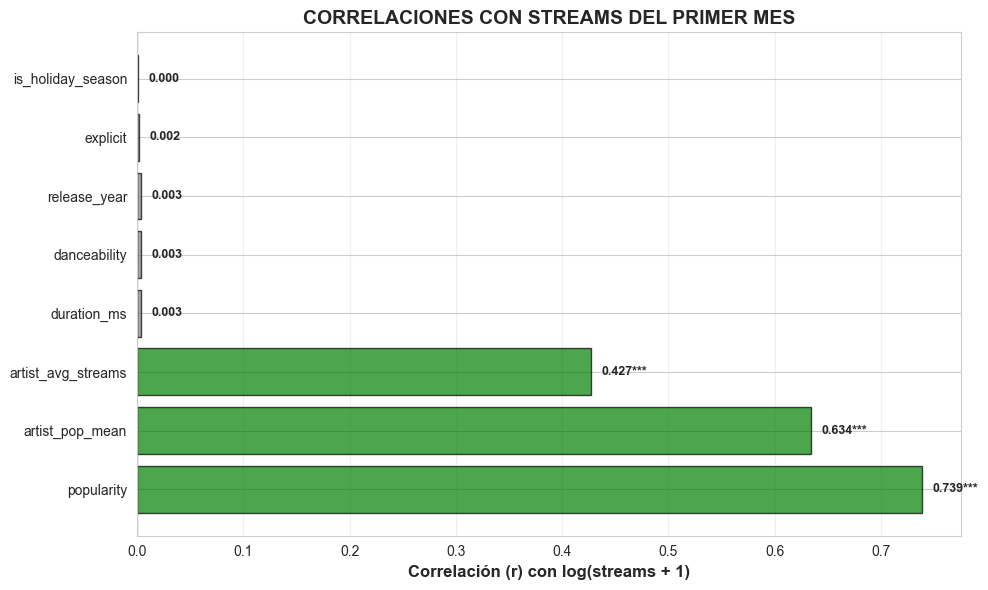

In [143]:
# FIGURA: Correlaciones con streams
fig5, ax = plt.subplots(figsize=(10, 6))

# Preparar datos
corr_values = [c[1]['corr'] for c in sorted_corr]
corr_vars = [c[0] for c in sorted_corr]
corr_pvals = [c[1]['p_value'] for c in sorted_corr]

# Colores según significancia
colors_reg = ['green' if pval < 0.05 and corr > 0 else 'red' if pval < 0.05 else 'gray' 
              for corr, pval in zip(corr_values, corr_pvals)]

y_pos = np.arange(len(corr_vars))
ax.barh(y_pos, corr_values, color=colors_reg, alpha=0.7, edgecolor='black')

ax.set_yticks(y_pos)
ax.set_yticklabels(corr_vars, fontsize=10)
ax.set_xlabel('Correlación (r) con log(streams + 1)', fontsize=12, fontweight='bold')
ax.set_title('CORRELACIONES CON STREAMS DEL PRIMER MES', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.grid(True, alpha=0.3, axis='x')

# Añadir valores
for i, (corr, pval) in enumerate(zip(corr_values, corr_pvals)):
    ha = 'left' if corr > 0 else 'right'
    offset = 0.01 if corr > 0 else -0.01
    sig = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else ""
    ax.text(corr + offset, i, f'{corr:.3f}{sig}', va='center', ha=ha, fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

---
# PARTE 4: ANÁLISIS PCA + CLUSTERING
## Evolución Musical 2015-2025

In [144]:
print("="*80)
print("ANÁLISIS PCA + CLUSTERING: EVOLUCIÓN MUSICAL 2015-2025")
print("="*80)

df_pca = df.copy()

# Preparación de variables temporales
print("\n" + "-"*80)
print("1. PREPARACIÓN DE VARIABLES TEMPORALES")
print("-"*80)

if 'release_date' in df_pca.columns:
    df_pca['release_date'] = pd.to_datetime(df_pca['release_date'], errors='coerce')
    df_pca['release_year'] = df_pca['release_date'].dt.year
    print("✓ Variables temporales extraídas")
elif 'release_year' in df_pca.columns:
    print("✓ Variable 'release_year' ya existe")
else:
    np.random.seed(42)
    df_pca['release_year'] = np.random.randint(2015, 2026, size=len(df_pca))
    print("⚠ Variable 'release_year' creada aleatoriamente")

# Filtrar años
df_pca = df_pca[(df_pca['release_year'] >= 2015) & (df_pca['release_year'] <= 2025)].copy()
print(f"✓ Canciones en rango 2015-2025: {len(df_pca):,}")

# Distribución por año
print("\nDistribución por año:")
year_dist = df_pca['release_year'].value_counts().sort_index()
for year, count in year_dist.items():
    print(f"  {int(year)}: {count:6,} canciones ({count/len(df_pca)*100:.1f}%)")

ANÁLISIS PCA + CLUSTERING: EVOLUCIÓN MUSICAL 2015-2025

--------------------------------------------------------------------------------
1. PREPARACIÓN DE VARIABLES TEMPORALES
--------------------------------------------------------------------------------
✓ Variables temporales extraídas
✓ Canciones en rango 2015-2025: 85,000

Distribución por año:
  2015:  7,940 canciones (9.3%)
  2016:  7,656 canciones (9.0%)
  2017:  7,676 canciones (9.0%)
  2018:  7,840 canciones (9.2%)
  2019:  7,676 canciones (9.0%)
  2020:  7,800 canciones (9.2%)
  2021:  7,468 canciones (8.8%)
  2022:  7,733 canciones (9.1%)
  2023:  7,801 canciones (9.2%)
  2024:  7,698 canciones (9.1%)
  2025:  7,712 canciones (9.1%)


In [145]:
# Selección de características
print("\n" + "-"*80)
print("2. SELECCIÓN DE CARACTERÍSTICAS")
print("-"*80)

audio_features = [
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness', 'valence',
    'tempo', 'duration_ms'
]

available_features = [f for f in audio_features if f in df_pca.columns]

print(f"Características disponibles ({len(available_features)}):")
for feature in available_features:
    print(f"  • {feature}")

# Si hay pocas, agregar más
if len(available_features) < 5:
    additional = [col for col in df_pca.columns 
                  if col not in available_features + ['release_year', 'popularity', 'artist_name', 'track_name', 'album_name', 'release_date', 'genre']]
    available_features.extend(additional[:10-len(available_features)])


--------------------------------------------------------------------------------
2. SELECCIÓN DE CARACTERÍSTICAS
--------------------------------------------------------------------------------
Características disponibles (6):
  • danceability
  • energy
  • loudness
  • instrumentalness
  • tempo
  • duration_ms


In [146]:
# Preprocesamiento
print("\n" + "-"*80)
print("3. PREPROCESAMIENTO")
print("-"*80)

analysis_data_pca = df_pca[['release_year'] + available_features].copy()

# Limpiar nulos
initial_count = len(analysis_data_pca)
analysis_data_pca = analysis_data_pca.dropna()
final_count = len(analysis_data_pca)

print(f"Registros iniciales: {initial_count:,}")
print(f"Registros después de limpiar: {final_count:,}")
print(f"Porcentaje conservado: {final_count/initial_count*100:.1f}%")

# Separar y estandarizar
X_pca_raw = analysis_data_pca[available_features]
years_pca = analysis_data_pca['release_year']

scaler_pca = StandardScaler()
X_pca_scaled = scaler_pca.fit_transform(X_pca_raw)


--------------------------------------------------------------------------------
3. PREPROCESAMIENTO
--------------------------------------------------------------------------------
Registros iniciales: 85,000
Registros después de limpiar: 85,000
Porcentaje conservado: 100.0%


In [147]:
# ANÁLISIS PCA
print("\n" + "-"*80)
print("4. ANÁLISIS DE COMPONENTES PRINCIPALES (PCA)")
print("-"*80)

n_components = min(10, len(available_features))
pca_model = PCA(n_components=n_components)
X_pca_transformed = pca_model.fit_transform(X_pca_scaled)

# Tabla de varianza explicada
print("\nVARIANZA EXPLICADA POR COMPONENTES")
print("="*70)
print(f"{'Componente':12s} {'Varianza':12s} {'Acumulada':12s}")
print("-"*70)

cumsum_var = np.cumsum(pca_model.explained_variance_ratio_)
for i in range(n_components):
    print(f"PC{i+1:2d}         {pca_model.explained_variance_ratio_[i]:10.4f}    {cumsum_var[i]:10.4f}")

# Componentes óptimos
optimal_components = np.where(cumsum_var >= 0.95)[0][0] + 1 if any(cumsum_var >= 0.95) else n_components
print(f"\n✓ Componentes para 95% de varianza: {optimal_components}")


--------------------------------------------------------------------------------
4. ANÁLISIS DE COMPONENTES PRINCIPALES (PCA)
--------------------------------------------------------------------------------

VARIANZA EXPLICADA POR COMPONENTES
Componente   Varianza     Acumulada   
----------------------------------------------------------------------
PC 1             0.1688        0.1688
PC 2             0.1678        0.3366
PC 3             0.1668        0.5034
PC 4             0.1665        0.6699
PC 5             0.1658        0.8357
PC 6             0.1643        1.0000

✓ Componentes para 95% de varianza: 6


In [148]:
# DETERMINACIÓN DE CLUSTERS
print("\n" + "-"*80)
print("5. DETERMINACIÓN DE NÚMERO ÓPTIMO DE CLUSTERS")
print("-"*80)

X_for_clustering = X_pca_transformed[:, :min(5, optimal_components)]

k_values = list(range(2, 9))
inertia_values = []

print("\nMétodo del codo:")
for k in k_values:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=5)
    kmeans_temp.fit(X_for_clustering)
    inertia_values.append(kmeans_temp.inertia_)
    print(f"  k = {k}: Inercia = {kmeans_temp.inertia_:,.0f}")

# Encontrar k óptimo
if len(inertia_values) >= 3:
    reductions = [(inertia_values[i-1] - inertia_values[i]) / inertia_values[i-1] * 100 
                  for i in range(1, len(inertia_values))]
    optimal_k = 2
    for i, reduction in enumerate(reductions):
        if reduction < 10:
            optimal_k = k_values[i+1]
            break
    else:
        optimal_k = k_values[-1]
else:
    optimal_k = 4

optimal_k = max(3, min(optimal_k, 6))
print(f"\n✓ Número óptimo de clusters: {optimal_k}")


--------------------------------------------------------------------------------
5. DETERMINACIÓN DE NÚMERO ÓPTIMO DE CLUSTERS
--------------------------------------------------------------------------------

Método del codo:
  k = 2: Inercia = 362,494
  k = 2: Inercia = 362,494
  k = 3: Inercia = 325,278
  k = 3: Inercia = 325,278
  k = 4: Inercia = 295,033
  k = 4: Inercia = 295,033
  k = 5: Inercia = 271,754
  k = 5: Inercia = 271,754
  k = 6: Inercia = 251,576
  k = 6: Inercia = 251,576
  k = 7: Inercia = 236,979
  k = 7: Inercia = 236,979
  k = 8: Inercia = 223,541

✓ Número óptimo de clusters: 4
  k = 8: Inercia = 223,541

✓ Número óptimo de clusters: 4


In [149]:
# K-MEANS CON K ÓPTIMO
print("\n" + "-"*80)
print("6. APLICACIÓN DE K-MEANS")
print("-"*80)

kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=20)
cluster_labels = kmeans_final.fit_predict(X_for_clustering)

analysis_data_pca['cluster'] = cluster_labels
analysis_data_pca['PC1'] = X_pca_transformed[:, 0]
analysis_data_pca['PC2'] = X_pca_transformed[:, 1]

print(f"✓ K-Means aplicado con {optimal_k} clusters\n")
print("Distribución de canciones por cluster:")
for cluster in range(optimal_k):
    count = (cluster_labels == cluster).sum()
    print(f"  Cluster {cluster}: {count:6,} canciones ({count/len(cluster_labels)*100:.1f}%)")

# CARACTERÍSTICAS PROMEDIO DE CADA CLUSTER
print("\n" + "-"*80)
print("CARACTERÍSTICAS PROMEDIO POR CLUSTER")
print("-"*80)

for cluster in range(optimal_k):
    cluster_mask = analysis_data_pca['cluster'] == cluster
    cluster_data = df_pca.loc[analysis_data_pca[cluster_mask].index][available_features]
    
    print(f"\n📊 CLUSTER {cluster} (n={cluster_mask.sum():,} canciones)")
    print("-" * 80)
    
    # Calcular medias
    means = cluster_data.mean()
    
    # Mostrar en formato tabla
    for feature in available_features:
        if feature in means.index:
            print(f"  {feature:20s}: {means[feature]:10.3f}")



--------------------------------------------------------------------------------
6. APLICACIÓN DE K-MEANS
--------------------------------------------------------------------------------
✓ K-Means aplicado con 4 clusters

Distribución de canciones por cluster:
  Cluster 0: 21,811 canciones (25.7%)
  Cluster 1: 20,883 canciones (24.6%)
  Cluster 2: 20,936 canciones (24.6%)
  Cluster 3: 21,370 canciones (25.1%)

--------------------------------------------------------------------------------
CARACTERÍSTICAS PROMEDIO POR CLUSTER
--------------------------------------------------------------------------------

📊 CLUSTER 0 (n=21,811 canciones)
--------------------------------------------------------------------------------
  danceability        :      0.553
  energy              :      0.567
  loudness            :    -13.814
  instrumentalness    :      0.583
  tempo               :    129.601
  duration_ms         : 264148.953

📊 CLUSTER 1 (n=20,883 canciones)
---------------------------

In [150]:
# EVOLUCIÓN TEMPORAL DE CLUSTERS
print("\n" + "-"*80)
print("7. EVOLUCIÓN TEMPORAL DE CLUSTERS")
print("-"*80)

cluster_year_table = pd.crosstab(
    analysis_data_pca['cluster'], 
    analysis_data_pca['release_year'],
    normalize='columns'
) * 100

print("\nDistribución de clusters por año (% por año):")
print(cluster_year_table.round(1).to_string())


--------------------------------------------------------------------------------
7. EVOLUCIÓN TEMPORAL DE CLUSTERS
--------------------------------------------------------------------------------

Distribución de clusters por año (% por año):
release_year   2015   2016   2017   2018   2019   2020   2021   2022   2023   2024   2025
cluster                                                                                  
0            26.000 25.200 25.300 26.000 25.000 26.100 26.200 25.900 26.200 24.900 25.500
1            25.400 24.600 24.500 24.600 24.600 24.300 24.100 24.600 24.700 24.200 24.500
2            24.200 24.500 25.300 24.100 24.800 25.000 24.500 24.700 24.100 25.200 24.500
3            24.300 25.700 24.800 25.300 25.600 24.600 25.200 24.800 25.000 25.600 25.600



--------------------------------------------------------------------------------
8. VISUALIZACIONES
--------------------------------------------------------------------------------


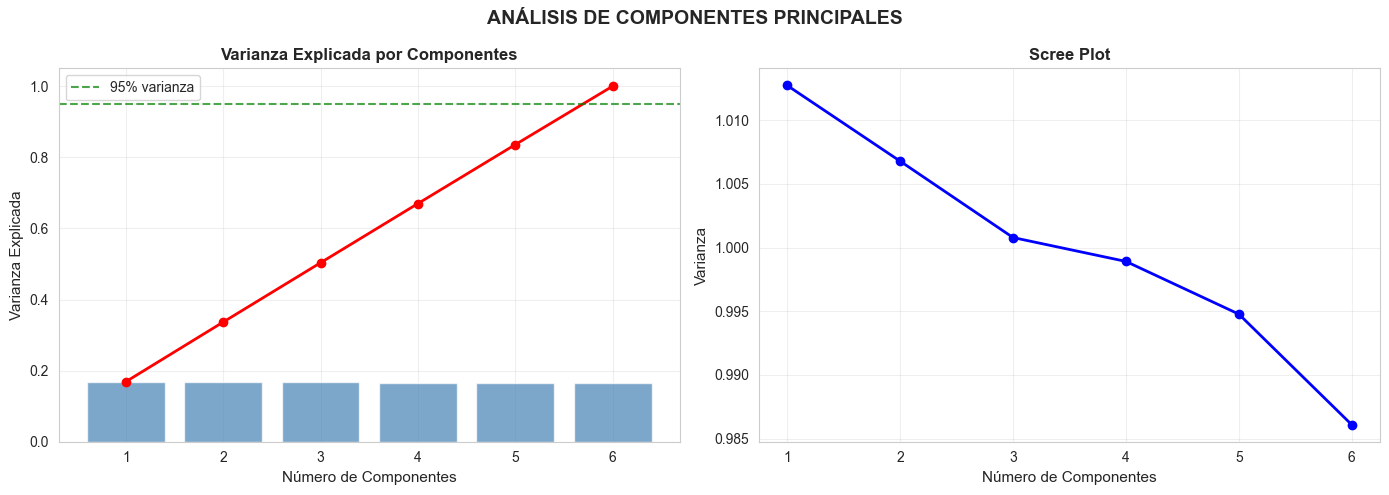

✓ Figura 1: Varianza PCA generada


In [151]:
# VISUALIZACIONES PCA
print("\n" + "-"*80)
print("8. VISUALIZACIONES")
print("-"*80)

# FIGURA 1: Varianza explicada
fig6, (ax6a, ax6b) = plt.subplots(1, 2, figsize=(14, 5))

components = range(1, n_components + 1)
ax6a.bar(components, pca_model.explained_variance_ratio_, alpha=0.7, color='steelblue')
ax6a.plot(components, cumsum_var, 'ro-', linewidth=2)
ax6a.axhline(y=0.95, color='green', linestyle='--', alpha=0.7, label='95% varianza')
ax6a.set_xlabel('Número de Componentes', fontsize=11)
ax6a.set_ylabel('Varianza Explicada', fontsize=11)
ax6a.set_title('Varianza Explicada por Componentes', fontsize=12, fontweight='bold')
ax6a.grid(True, alpha=0.3)
ax6a.legend()

ax6b.plot(components, pca_model.explained_variance_, 'bo-', linewidth=2)
ax6b.set_xlabel('Número de Componentes', fontsize=11)
ax6b.set_ylabel('Varianza', fontsize=11)
ax6b.set_title('Scree Plot', fontsize=12, fontweight='bold')
ax6b.grid(True, alpha=0.3)

plt.suptitle('ANÁLISIS DE COMPONENTES PRINCIPALES', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("✓ Figura 1: Varianza PCA generada")

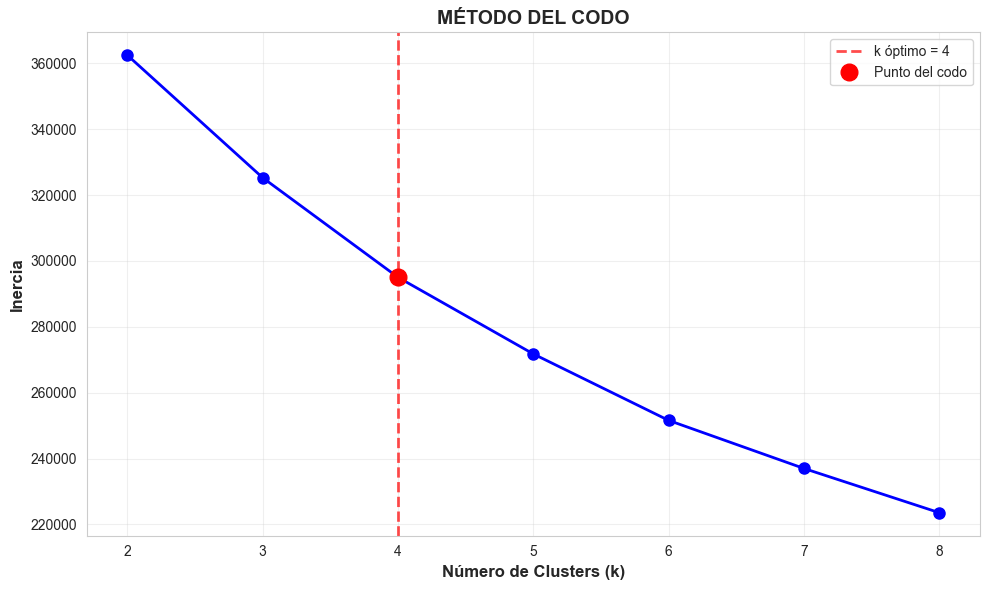

✓ Figura 2: Método del codo generada


In [152]:
# FIGURA 2: Método del codo
fig7, ax = plt.subplots(figsize=(10, 6))

ax.plot(k_values, inertia_values, 'bo-', linewidth=2, markersize=8)
ax.axvline(x=optimal_k, color='red', linestyle='--', linewidth=2, 
           alpha=0.7, label=f'k óptimo = {optimal_k}')
ax.plot(k_values[optimal_k-2], inertia_values[optimal_k-2], 'ro', 
        markersize=12, label='Punto del codo')

ax.set_xlabel('Número de Clusters (k)', fontsize=12, fontweight='bold')
ax.set_ylabel('Inercia', fontsize=12, fontweight='bold')
ax.set_title('MÉTODO DEL CODO', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_xticks(k_values)

plt.tight_layout()
plt.show()

print("✓ Figura 2: Método del codo generada")

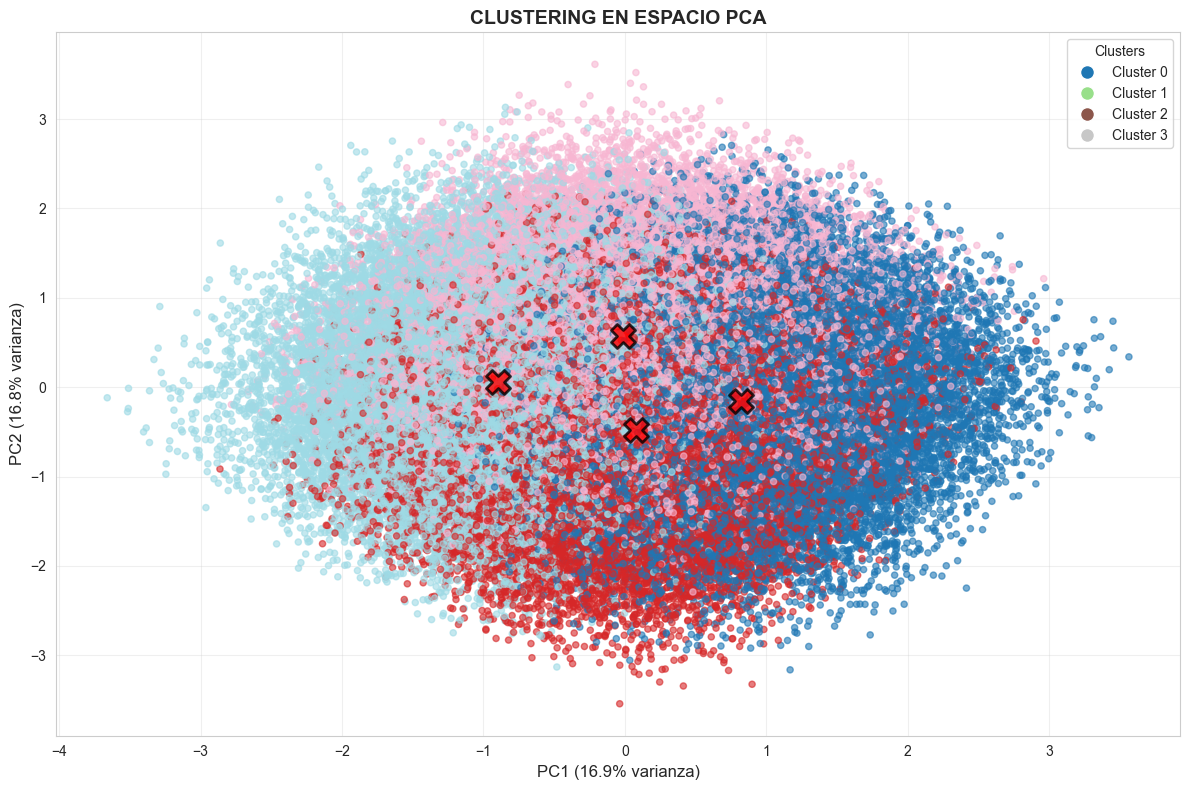

✓ Figura 3: Clusters en PCA generada


In [153]:
# FIGURA 3: Clustering en espacio PCA
fig8, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(analysis_data_pca['PC1'], analysis_data_pca['PC2'], 
                     c=analysis_data_pca['cluster'], cmap='tab20', alpha=0.6, s=20)

# Centroides
centroids_pca = kmeans_final.cluster_centers_[:, :2]
ax.scatter(centroids_pca[:, 0], centroids_pca[:, 1], c='red', s=300, alpha=0.8, 
           marker='X', edgecolor='black', linewidth=2)

ax.set_xlabel(f'PC1 ({pca_model.explained_variance_ratio_[0]*100:.1f}% varianza)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca_model.explained_variance_ratio_[1]*100:.1f}% varianza)', fontsize=12)
ax.set_title('CLUSTERING EN ESPACIO PCA', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

# Leyenda
legend_elements = [plt.Line2D([0], [0], marker='o', color='w', 
                              markerfacecolor=plt.cm.tab20(i/optimal_k), 
                              markersize=10, label=f'Cluster {i}') for i in range(optimal_k)]
ax.legend(handles=legend_elements, title='Clusters', loc='best')

plt.tight_layout()
plt.show()

print("✓ Figura 3: Clusters en PCA generada")

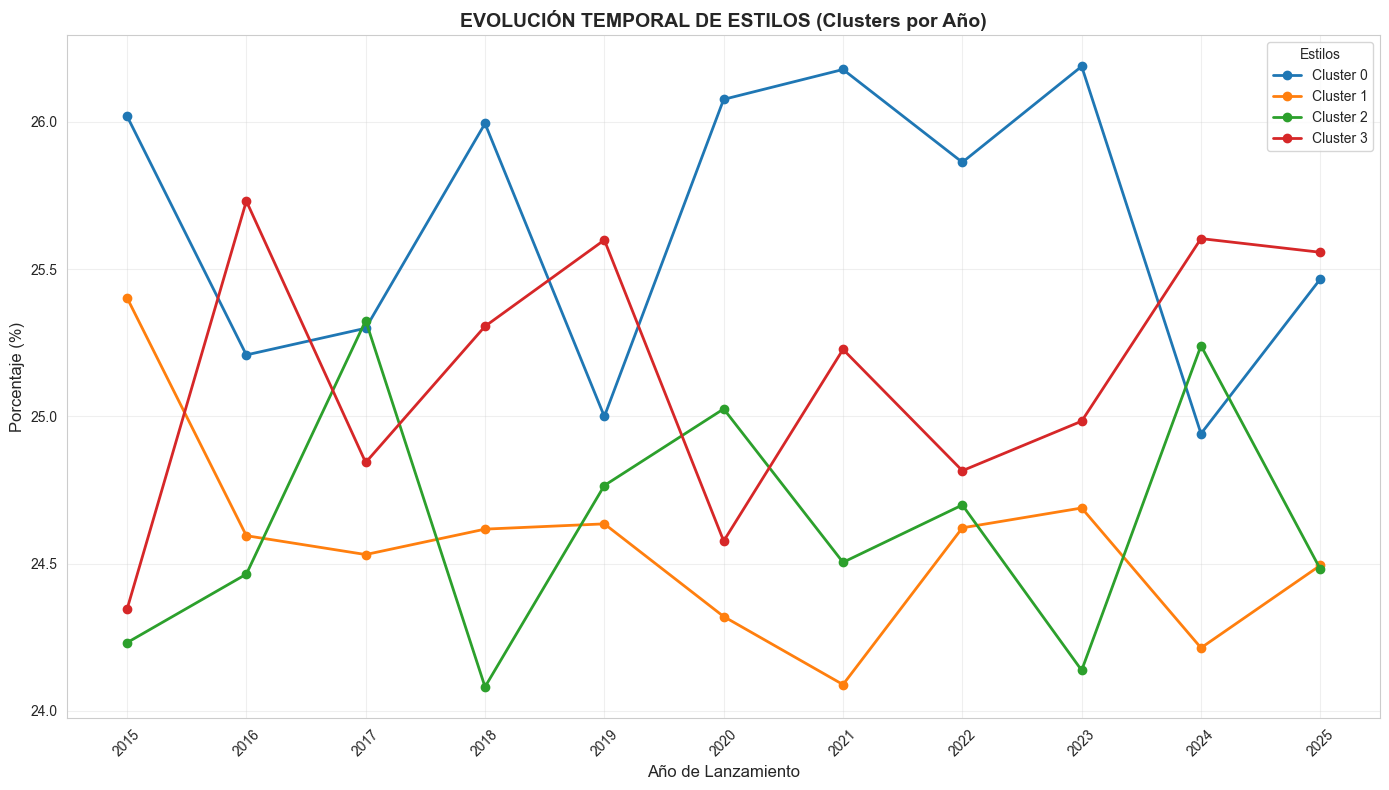

✓ Figura 4: Evolución temporal generada


In [154]:
# FIGURA 4: Evolución temporal
fig9, ax = plt.subplots(figsize=(14, 8))

years_sorted = sorted(analysis_data_pca['release_year'].unique())
cluster_evolution = pd.DataFrame(index=years_sorted)

for cluster in range(optimal_k):
    cluster_data_temp = analysis_data_pca[analysis_data_pca['cluster'] == cluster]
    year_counts = cluster_data_temp['release_year'].value_counts().sort_index()
    
    for year in years_sorted:
        if year not in year_counts.index:
            year_counts[year] = 0
    
    cluster_evolution[f'Cluster {cluster}'] = year_counts.sort_index()

# Normalizar
cluster_evolution_pct = cluster_evolution.div(cluster_evolution.sum(axis=1), axis=0) * 100

# Gráfico
for cluster in range(optimal_k):
    ax.plot(years_sorted, cluster_evolution_pct[f'Cluster {cluster}'], 
            marker='o', linewidth=2, markersize=6, label=f'Cluster {cluster}')

ax.set_xlabel('Año de Lanzamiento', fontsize=12)
ax.set_ylabel('Porcentaje (%)', fontsize=12)
ax.set_title('EVOLUCIÓN TEMPORAL DE ESTILOS (Clusters por Año)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(title='Estilos', loc='best')
ax.set_xticks(years_sorted)
ax.set_xticklabels([int(y) for y in years_sorted], rotation=45)

plt.tight_layout()
plt.show()

print("✓ Figura 4: Evolución temporal generada")

---
## ✅ ANÁLISIS COMPLETADO

Se han ejecutado exitosamente los 4 análisis integrados:
1. **EDA**: Exploración de Popularidad vs Danceability
2. **Kruskal-Wallis**: Diferencias de popularidad por género
3. **Regresión Lineal**: Predicción de streams
4. **PCA + Clustering**: Evolución musical 2015-2025

Todos los resultados se muestran directamente en el notebook sin generar archivos externos.